# Local LLMs

The LLM explosion offers opportunities for using models without any knowledge, is it? Or not? 

## Image classification



--------------------------
datasets/musti/cat_back.jpg: CAT


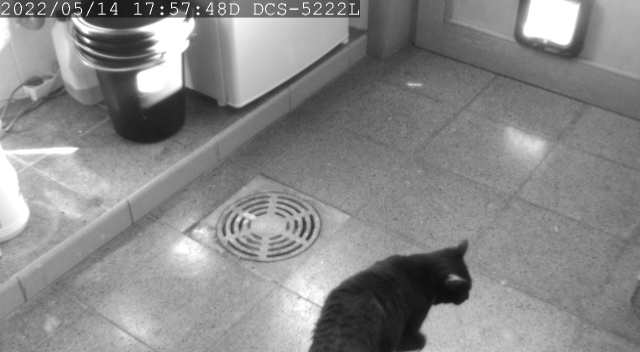

--------------------------
datasets/musti/cat_front.jpg: CAT


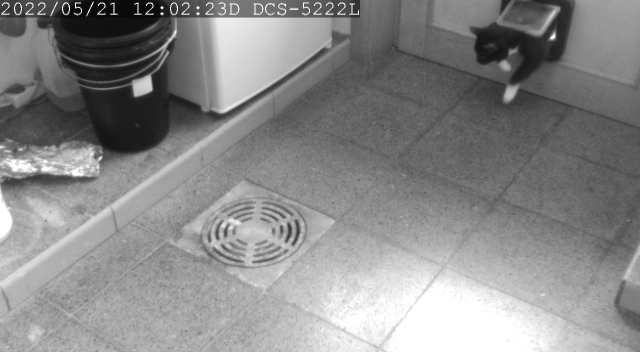

--------------------------
datasets/musti/cat_tail.jpg: CAT


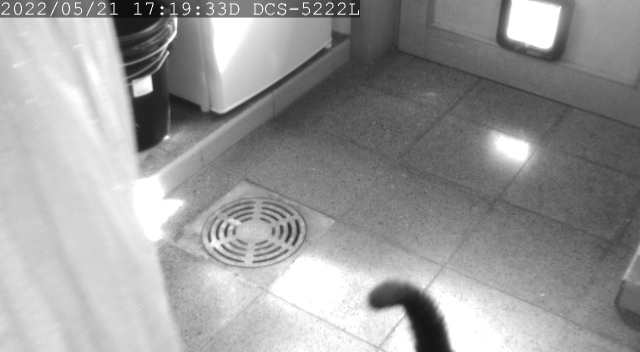

--------------------------
datasets/musti/cat_window.jpg: NONE


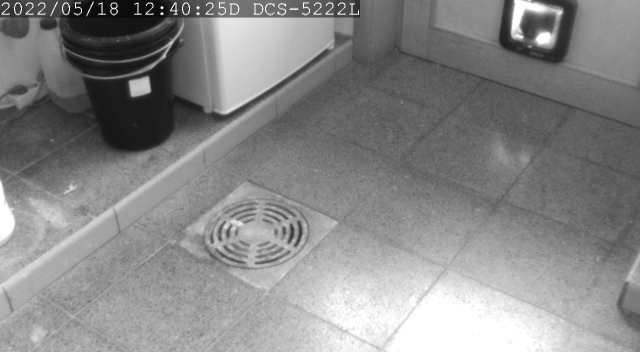

--------------------------
datasets/musti/human_body.jpg: HUMAN


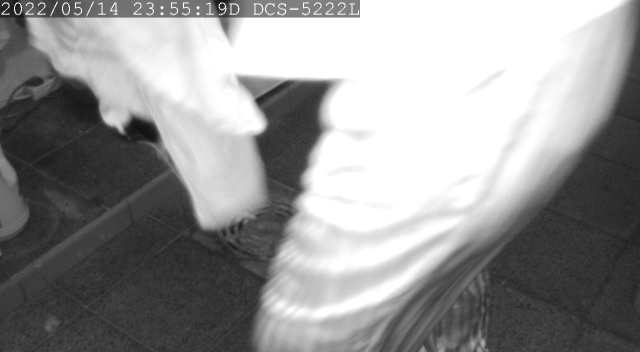

--------------------------
datasets/musti/human_feet.jpg: PERSON


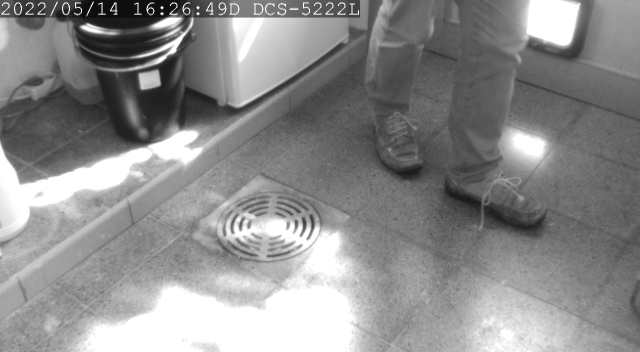

--------------------------
datasets/musti/nothing.jpg: NONE


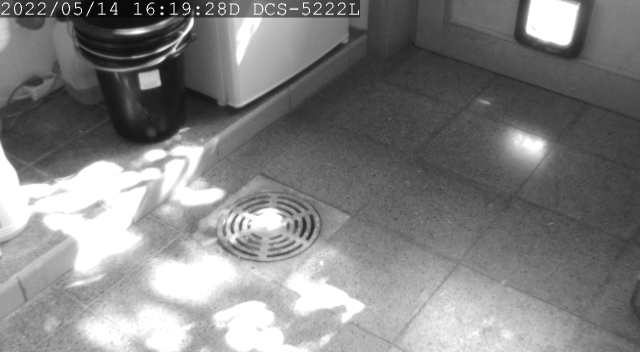

--------------------------


In [1]:
import base64
import os
from PIL import Image
from dotenv import load_dotenv, find_dotenv
from groq import Groq

load_dotenv(find_dotenv(usecwd=True))
MODEL = "meta-llama/llama-4-scout-17b-16e-instruct"
USER_PROMPT = "Is there a living being in the image? Just give the name of the living being (without dot) in uppercase. "
USER_PROMPT += "If no living being visible then say NONE."
groq_client = Groq(api_key=os.environ.get("GROQ_API_KEY"))

musti_path = "datasets/musti" 
images = os.listdir(musti_path)
images = [musti_path + "/" + image for image in images]

print("--------------------------")
for image in images: 

        with open(image, "rb") as image_file:
            base64_image = base64.b64encode(image_file.read()).decode('utf-8')

        completion = groq_client.chat.completions.create(
            model=MODEL,
            messages=[
                {
                    "role": "user",
                    "content": [
                        {
                            "type": "text",
                            "text": USER_PROMPT
                        },
                        {
                            "type": "image_url",
                            "image_url": {
                                "url": f"data:image/jpeg;base64,{base64_image}",
                            }
                        }
                    ]
                }
            ],
            # Temperatur controls randomness in token sampling. 
            # Lower values make outputs more deterministic; higher values make them more diverse/creative.
            temperature=0,   
            # top_p limits sampling to the smallest set of tokens whose cumulative probability ≥ p.
            top_p=0.5,
            stream=False,
            stop=None,
        )

        being = completion.choices[0].message.content
        print(f"{image}: {being}")
        display(Image.open(image))
        print("--------------------------")


## Exercise

Take a few pictures with your mobile phone and classify them using a local LMM. 